# Informations de soumission

- **Nom** : Aldiouma Mbaye
- **Matiere** : Big Data
- **Professeur** : ZITOUNI Rabiaa
- **Repository GitHub (code complet)** : https://github.com/maldiouma/Big-Data.git

> Ce notebook est le livrable principal. Le code complet du projet est disponible sur le repository GitHub ci-dessus si besoin de verification detaillee.

## PARTIE A : GÉNÉRATION DU DATASET

### Objectif : Créer 5000 candidats avec 8 matières chacun

**Fichiers à générer :**
1. **candidats.txt** : Num_CIN Nom Prenom Filiere
2. **notes.txt** : Num_CIN + 8 notes (0-20)
3. **choix.txt** : Num_CIN Choix1 Choix2 Choix3
4. **filiere.json** : Dictionnaire {code: [école, capacité]}

In [4]:
# Importer les modules necessaires
import sys
import os
import io
import re
from contextlib import redirect_stdout

# Ajouter le dossier scripts au chemin
sys.path.insert(0, 'scripts')

from generation_dataset import (
    creation_liste_candidats,
    creation_notes,
    creation_choix,
    creation_filiere,
    generer_dataset_complet
)

def afficher_sortie_texte(fonction, *args, **kwargs):
    """Execute une fonction et nettoie la sortie pour garder uniquement du texte."""
    buffer = io.StringIO()
    with redirect_stdout(buffer):
        resultat = fonction(*args, **kwargs)

    texte = buffer.getvalue()
    texte = re.sub(r'([0-9])\ufe0f?\u20e3', r'\1.', texte)
    texte = texte.replace('✓', 'OK').replace('✗', 'NON')
    texte = texte.replace('•', '-')
    texte = re.sub(r'[\U0001F300-\U0001FAFF]', '', texte)
    texte = re.sub(r'[\u2600-\u27BF]', '', texte)
    print(texte)
    return resultat

print("Modules importes avec succes.")

Modules importes avec succes.


In [5]:
# ETAPE 1 : Generer le dataset complet
print("\n" + "=" * 70)
print("ETAPE 1 : GENERATION DU DATASET MASSIF")
print("=" * 70 + "\n")

afficher_sortie_texte(generer_dataset_complet, 5000)


ETAPE 1 : GENERATION DU DATASET MASSIF


GÉNÉRATION DU DATASET COMPLET

1.  Génération des candidats...
OK 5000 candidats sauvegardés dans data/candidats.txt

2.  Génération des notes...
OK Notes de 5000 candidats sauvegardées dans data/notes.txt

3.  Création du dictionnaire des filières...
OK Dictionnaire des filières sauvegardé dans data/filiere.json

4.  Génération des choix de filière...
OK Choix de 5000 candidats sauvegardés dans data/choix.txt

 DATASET COMPLET GÉNÉRÉ (5000 candidats)

 STATISTIQUES DU DATASET :
   - Nombre de candidats : 5000
   - Filière MP : 2535
   - Filière PC : 2465
   - Nombre de filières : 5




### Résultat de la Génération :
 **5000 candidats** générés  
 **40,000 notes** créées (5000 × 8 matières)  
 **15,000 choix** assignés (5000 × 3 choix)  
**5 filières** avec capacités définies

**Fichiers créés dans `data/` :**

In [3]:
# Vérifier les fichiers générés
import os

dossier_data = "data"
print(f"\n Fichiers dans '{dossier_data}' :\n")
print(f"{'Fichier':<20} {'Taille':<15} {'Lignes':<10}")
print("-"*50)

for fichier in sorted(os.listdir(dossier_data)):
    chemin = os.path.join(dossier_data, fichier)
    size = os.path.getsize(chemin) / 1024  # KB
    
    # Compter les lignes
    if fichier.endswith(('.txt', '.json')):
        with open(chemin, 'r', encoding='utf-8') as f:
            lignes = len(f.readlines())
        print(f"{fichier:<20} {size:>8.2f} KB    {lignes:>8}")

print("-"*50)


 Fichiers dans 'data' :

Fichier              Taille          Lignes    
--------------------------------------------------
candidats.txt          116.98 KB        5001
choix.txt              112.33 KB        5001
filiere.json             0.29 KB          22
notes.txt              258.13 KB        5001
--------------------------------------------------


In [4]:
# Afficher un aperçu des données
print("\n APERÇU DES DONNÉES\n")

print("Candidats.txt (5 premières lignes) :")
print("-"*60)
with open("data/candidats.txt", 'r', encoding='utf-8') as f:
    for i, ligne in enumerate(f):
        if i < 6:
            print(ligne.strip())
        else:
            break


 APERÇU DES DONNÉES

Candidats.txt (5 premières lignes) :
------------------------------------------------------------
Num_CIN Nom Prenom Filiere
000001 HANA Noor PC
000002 TAHA Samira PC
000003 AHMED Hassan MP
000004 AMIRA Fatima PC
000005 KARIM Nadia PC


In [5]:
print("\nNotes.txt (3 premières lignes) :")
print("-"*60)
with open("data/notes.txt", 'r', encoding='utf-8') as f:
    for i, ligne in enumerate(f):
        if i < 3:
            print(ligne.strip())
        else:
            break


Notes.txt (3 premières lignes) :
------------------------------------------------------------
Num_CIN Analyse Algèbre Physique Chimie Informatique STA Français Anglais
000001 11.76 17.15 10.61 11.77 9.63 10.83 15.37 14.08
000002 18.11 5.09 6.66 12.82 9.55 2.93 14.54 14.21


In [6]:
print("\nFiliere.json :")
print("-"*60)
import json
with open("data/filiere.json", 'r', encoding='utf-8') as f:
    filieres = json.load(f)
    for code, info in filieres.items():
        print(f"{code} : {info[0]:30s} → Capacité: {info[1]} places")


Filiere.json :
------------------------------------------------------------
E101 : École d'Ingénierie MP          → Capacité: 200 places
E205 : École d'Ingénierie PC          → Capacité: 150 places
E301 : École Polytechnique            → Capacité: 100 places
E402 : Institut Technologique         → Capacité: 180 places
E503 : École Managériale              → Capacité: 250 places


---
## PARTIE B & C : MAPREDUCE - CALCUL DU SCORE FG ET CLASSEMENT

### Formule du Score FG (Score Global Pondéré) :

$$FG = \text{Analyse} \times 8 + \text{Algèbre} \times 6 + \text{Physique} \times 8 + \text{Chimie} \times 6$$
$$+ \text{Informatique} \times 6 + \text{STA} \times 4 + \text{Français} \times 3 + \text{Anglais} \times 3$$

**Explication des poids :**
- **Analyse (8)** & **Physique (8)** : Disciplines fondamentales
- **Algèbre (6)**, **Chimie (6)**, **Informatique (6)** : Sciences appliquées
- **STA (4)** : Statistiques et probabilités
- **Français (3)** & **Anglais (3)** : Langues

In [3]:
# Importer les modules MapReduce
from mapreduce_job import job_mapreduce_score_fg

print("\n" + "=" * 70)
print("ETAPE 2 : MAPREDUCE - CALCUL DU SCORE FG ET CLASSEMENT")
print("=" * 70 + "\n")

# Executer le job MapReduce
resultats_tries = afficher_sortie_texte(job_mapreduce_score_fg)


ETAPE 2 : MAPREDUCE - CALCUL DU SCORE FG ET CLASSEMENT


JOB MAPREDUCE : CALCUL DU SCORE FG ET RANG
 MAPPER : Chargement des candidats...
   OK 5000 candidats chargés
 MAPPER : Fusion avec les notes...
   OK 5000 candidats fusionnés

 REDUCER : Calcul des scores FG...
   OK 5000 scores FG calculés
 REDUCER : Tri par score FG décroissant...
 REDUCER : Attribution des rangs...
   OK 5000 candidats classés

 Génération du fichier rang.txt...
   OK Fichier data/rang.txt généré avec 5000 candidats

 JOB MAPREDUCE TERMINÉ

 STATISTIQUES DES RANGS :
   • Total candidats : 5000
   • Score FG minimal : 239.07
   • Score FG maximal : 737.13
   • Score FG moyen : 534.04

 TOP 10 DES MEILLEURS SCORES :
    1. 001885 - MOROCCO      Rabab        - FG: 737.13
    2. 001355 - OMAR         Hicham       - FG: 724.45
    3. 002689 - KARIM        Mohammed     - FG: 719.41
    4. 001803 - BENNANI      Ali          - FG: 718.21
    5. 000967 - KHALID       Fatima       - FG: 717.71
    6. 004939 - MOROCCO 

In [8]:
# Afficher un aperçu du fichier rang.txt
print("\n FICHIER RANG.TXT - TOP 10\n")
print(f"{'Rang':<6} {'Num_CIN':<10} {'Score FG':<15}")
print("-"*35)

with open("data/rang.txt", 'r', encoding='utf-8') as f:
    f.readline()  # Ignorer l'en-tête
    for i, ligne in enumerate(f):
        if i < 10:
            parties = ligne.strip().split()
            if len(parties) >= 3:
                num_cin = parties[0]
                fg = float(parties[1])
                rang = int(parties[2])
                print(f"{rang:<6} {num_cin:<10} {fg:>12.2f}")


 FICHIER RANG.TXT - TOP 10

Rang   Num_CIN    Score FG       
-----------------------------------
1      001382           732.64
2      003391           725.45
3      000615           723.50
4      001204           723.29
5      000264           723.16
6      004271           719.29
7      002695           707.78
8      001736           705.05
9      000410           704.62
10     000729           700.82


In [4]:
# Statistiques du classement
import numpy as np

scores_fg = []
with open("data/rang.txt", 'r', encoding='utf-8') as f:
    f.readline()
    for ligne in f:
        parties = ligne.strip().split()
        if len(parties) >= 2:
            scores_fg.append(float(parties[1]))

print("\nSTATISTIQUES DES SCORES FG\n")
print(f"Score minimum      : {min(scores_fg):.2f}")
print(f"Score maximum      : {max(scores_fg):.2f}")
print(f"Score moyen        : {np.mean(scores_fg):.2f}")
print(f"Score médian       : {np.median(scores_fg):.2f}")
print(f"Écart-type         : {np.std(scores_fg):.2f}")
print(f"\nTotal candidats classés : {len(scores_fg)}")


STATISTIQUES DES SCORES FG

Score minimum      : 280.05
Score maximum      : 740.67
Score moyen        : 532.32
Score médian       : 535.12
Écart-type         : 69.24

Total candidats classés : 5000


---
##  PARTIE D : HIVE - ANALYSES ANALYTIQUES

Exécution de 5 requêtes SQL analytiques pour comprendre les données :

In [6]:
# Importer les modules Hive
from hive_queries import executer_requetes_hive

print("\n" + "=" * 70)
print("ETAPE 3 : REQUETES HIVE - ANALYSES ANALYTIQUES")
print("=" * 70 + "\n")

# Executer toutes les requetes
afficher_sortie_texte(executer_requetes_hive)


ETAPE 3 : REQUETES HIVE - ANALYSES ANALYTIQUES


ANALYSE HIVE - REQUÊTES ANALYTIQUES

 Hive - Chargement des données dans les tables...
   OK Table 'candidats' : 5000 lignes
   OK Table 'notes' : 5000 lignes
   OK Table 'rang' : 5000 lignes
   OK Table 'choix' : 5000 lignes
   OK Table 'resultats' : 5000 lignes

EXÉCUTION DES REQUÊTES HIVE

 REQUÊTE HIVE #1 : Moyenne par matière
SELECT matiere, AVG(note) as moyenne FROM notes GROUP BY matiere

Matière              Moyenne         Min        Max       
----------------------------------------------------------------------
Algèbre               12.03<20   0.00           20.00
Analyse               12.10<20   0.00           19.97
Anglais               12.16<20   0.00           19.99
Chimie                12.00<20   0.01           19.96
Français              12.12<20   0.03           19.99
Informatique          12.09<20   0.01           19.99
Physique              12.03<20   0.02           19.99
STA                   12.10<20   0.01      

### Résultats Hive (résumé lisible)

Cette section affiche un résumé court des analyses Hive pour l'évaluation :
- moyenne des notes par matière
- statistiques FG (min, max, moyenne)
- répartition MP/PC
- top 10 des candidats par score FG

In [10]:
# Resume court des resultats Hive
from collections import defaultdict

# 1) Moyennes par matiere
with open("data/notes.txt", "r", encoding="utf-8") as f:
    entete = f.readline().strip().split()
    matieres = entete[1:]
    sommes = defaultdict(float)
    n = 0
    for ligne in f:
        parties = ligne.strip().split()
        if len(parties) != len(entete):
            continue
        notes = list(map(float, parties[1:]))
        for m, v in zip(matieres, notes):
            sommes[m] += v
        n += 1

moyennes = {m: (sommes[m] / n if n else 0.0) for m in matieres}

# 2) Statistiques FG + top 10
fg = []
top10 = []
with open("data/rang.txt", "r", encoding="utf-8") as f:
    f.readline()
    for ligne in f:
        p = ligne.strip().split()
        if len(p) >= 3:
            num = p[0]
            score = float(p[1])
            rang = int(p[2])
            fg.append(score)
            if rang <= 10:
                top10.append((rang, num, score))

# 3) Repartition MP/PC
dist = {"MP": 0, "PC": 0}
with open("data/candidats.txt", "r", encoding="utf-8") as f:
    f.readline()
    for ligne in f:
        p = ligne.strip().split()
        if len(p) >= 4 and p[3] in dist:
            dist[p[3]] += 1

total = dist["MP"] + dist["PC"]

print("RESUME HIVE")
print("=" * 60)
print("Moyennes par matiere:")
for m in matieres:
    print(f"- {m:<14}: {moyennes[m]:.2f}")

if fg:
    print("\nStatistiques FG:")
    print(f"- Minimum: {min(fg):.2f}")
    print(f"- Maximum: {max(fg):.2f}")
    print(f"- Moyenne: {sum(fg)/len(fg):.2f}")

print("\nRepartition des filieres (candidats):")
if total > 0:
    print(f"- MP: {dist['MP']} ({dist['MP']*100/total:.2f}%)")
    print(f"- PC: {dist['PC']} ({dist['PC']*100/total:.2f}%)")
else:
    print("- Donnees indisponibles")

print("\nTop 10 (Rang, Num_CIN, Score FG):")
for rang, num, score in sorted(top10):
    print(f"- {rang:>2} | {num} | {score:.2f}")

RESUME HIVE
Moyennes par matiere:
- Analyse       : 12.10
- Algèbre       : 12.03
- Physique      : 12.03
- Chimie        : 12.00
- Informatique  : 12.09
- STA           : 12.10
- Français      : 12.12
- Anglais       : 12.16

Statistiques FG:
- Minimum: 239.07
- Maximum: 737.13
- Moyenne: 534.04

Repartition des filieres (candidats):
- MP: 2535 (50.70%)
- PC: 2465 (49.30%)

Top 10 (Rang, Num_CIN, Score FG):
-  1 | 001885 | 737.13
-  2 | 001355 | 724.45
-  3 | 002689 | 719.41
-  4 | 001803 | 718.21
-  5 | 000967 | 717.71
-  6 | 004939 | 714.90
-  7 | 003667 | 711.66
-  8 | 002415 | 710.42
-  9 | 000549 | 709.87
- 10 | 001218 | 708.43


---
##  PARTIE E : HBASE - AFFECTATIONS NATIONALES

### Algorithme d'Affectation (Système Juste)

**Principe :**
1. Trier candidats par rang (meilleur au premier)
2. Pour chaque candidat :
   - Tester Choix1 disponible ? → Affecter
   - Sinon, tester Choix2 disponible ? → Affecter
   - Sinon, tester Choix3 disponible ? → Affecter
   - Sinon → Pas d'affectation (AUCUNE)
3. Décrémenter la capacité dans HBase à chaque affectation
4. Générer resultats.txt

In [7]:
# Importer les modules HBase
from hbase_operations import creation_resultat

print("\n" + "=" * 70)
print("ETAPE 4 : HBASE - AFFECTATIONS NATIONALES")
print("=" * 70 + "\n")

# Executer l'algorithme d'affectation
afficher_sortie_texte(creation_resultat)


ETAPE 4 : HBASE - AFFECTATIONS NATIONALES


ALGORITHME D'AFFECTATION - SYSTÈME D'ORIENTATION NATIONALE

 Étape 1 : Chargement des données...
   - Chargement des rangs...
     OK 5000 candidats chargés
   - Chargement des choix...
     OK 5000 candidats avec leurs choix
   - Chargement des filières...
     OK 5 filières chargées

 Étape 2 : Initialisation des tables HBase...
️  HBase - Création de la table FILIERE...
   OK Table FILIERE créée avec 5 filières
️  HBase - Création de la table CHOIX...
   OK Table CHOIX créée avec 5000 candidats
️  HBase - Création de la table RESULTATS...
   OK Table RESULTATS créée (vide)

 HBase SCAN - Table FILIERE :
--------------------------------------------------------------------------------
Code Filière    Nom École                      Capacité   Places Restantes
--------------------------------------------------------------------------------
E101            École d'Ingénierie MP          200        200            
E205            École d'Ingéni

In [12]:
# Statistiques d'affectation
affectations = {}
with open("data/resultats.txt", 'r', encoding='utf-8') as f:
    f.readline()
    for ligne in f:
        parties = ligne.strip().split()
        if len(parties) >= 2:
            filiere = parties[1]
            if filiere not in affectations:
                affectations[filiere] = 0
            affectations[filiere] += 1

print("\n RÉSUMÉ FINAL DES AFFECTATIONS\n")
print(f"{'Filière':<25} {'Affectés':<15} {'Pourcentage':<15}")
print("-"*60)

total = sum(affectations.values())
for filiere in sorted(affectations.keys()):
    nombre = affectations[filiere]
    pourcentage = (nombre / 5000 * 100)
    print(f"{filiere:<25} {nombre:<15} {pourcentage:>6.2f}%")

print("-"*60)
print(f"{'TOTAL':<25} {total:<15} {100.0:>6.2f}%")


 RÉSUMÉ FINAL DES AFFECTATIONS

Filière                   Affectés        Pourcentage    
------------------------------------------------------------
AUCUNE                    4120             82.40%
E101                      200               4.00%
E205                      150               3.00%
E301                      100               2.00%
E402                      180               3.60%
E503                      250               5.00%
------------------------------------------------------------
TOTAL                     5000            100.00%


---
##  PARTIE F : VISUALISATIONS

Création de 5 graphiques pour visualiser les données :

### Commentaires importants pour l'évaluation

- Le pipeline respecte l'enchaînement demandé : génération des données, calcul MapReduce, analyses Hive, affectation HBase, visualisation.
- Le classement est basé sur une formule pondérée explicite et reproductible.
- L'affectation respecte la priorité au mérite, puis les trois choix du candidat.
- La capacité totale des écoles est de 880 places pour 5000 candidats, ce qui explique un volume élevé de non-affectés.
- Les graphiques permettent de vérifier la cohérence statistique des notes et des scores FG.
- Tous les fichiers de sortie sont sauvegardés dans les dossiers data et visualisations.

In [8]:
# Importer les modules visualisations
import os
from visualisations import trace_courbes

print("\n" + "=" * 70)
print("ETAPE 5 : VISUALISATIONS")
print("=" * 70 + "\n")

fichiers_attendus = [
    "Histogrammes_Matieres.png",
    "Distribution_Filieres.png",
    "Courbe_Moyennes.png",
    "Histogramme_FG.png",
    "Repartition_Affectations.png",
]

dossier_visuals = "visualisations"
manquants = [
    f for f in fichiers_attendus
    if not os.path.exists(os.path.join(dossier_visuals, f))
]

if manquants:
    print("Graphiques manquants detectes. Generation en cours...")
    os.environ["OPENBLAS_NUM_THREADS"] = "1"
    os.environ["OMP_NUM_THREADS"] = "1"
    os.environ["MKL_NUM_THREADS"] = "1"
    try:
        afficher_sortie_texte(trace_courbes)
        print("Generation terminee.")
    except MemoryError:
        print("Memoire insuffisante pendant la generation.")
        print("Relancer cette cellule apres fermeture des autres applications.")
else:
    print("Les graphiques existent deja. Aucune regeneration necessaire.")


ETAPE 5 : VISUALISATIONS

Les graphiques existent deja. Aucune regeneration necessaire.


In [7]:
# Afficher les graphiques generes
import os

dossier_visuals = "visualisations"

if os.path.exists(dossier_visuals):
    fichiers_png = [f for f in os.listdir(dossier_visuals) if f.endswith('.png')]
    print(f"\n{len(fichiers_png)} graphiques generes dans '{dossier_visuals}/'\n")

    for fichier in sorted(fichiers_png):
        print(f"- {fichier}")


 4 graphiques générés dans 'visualisations/'

  • Courbe_Moyennes.png
  • Distribution_Filieres.png
  • Histogramme_FG.png
  • Histogrammes_Matieres.png



Histogrammes des notes par matiere


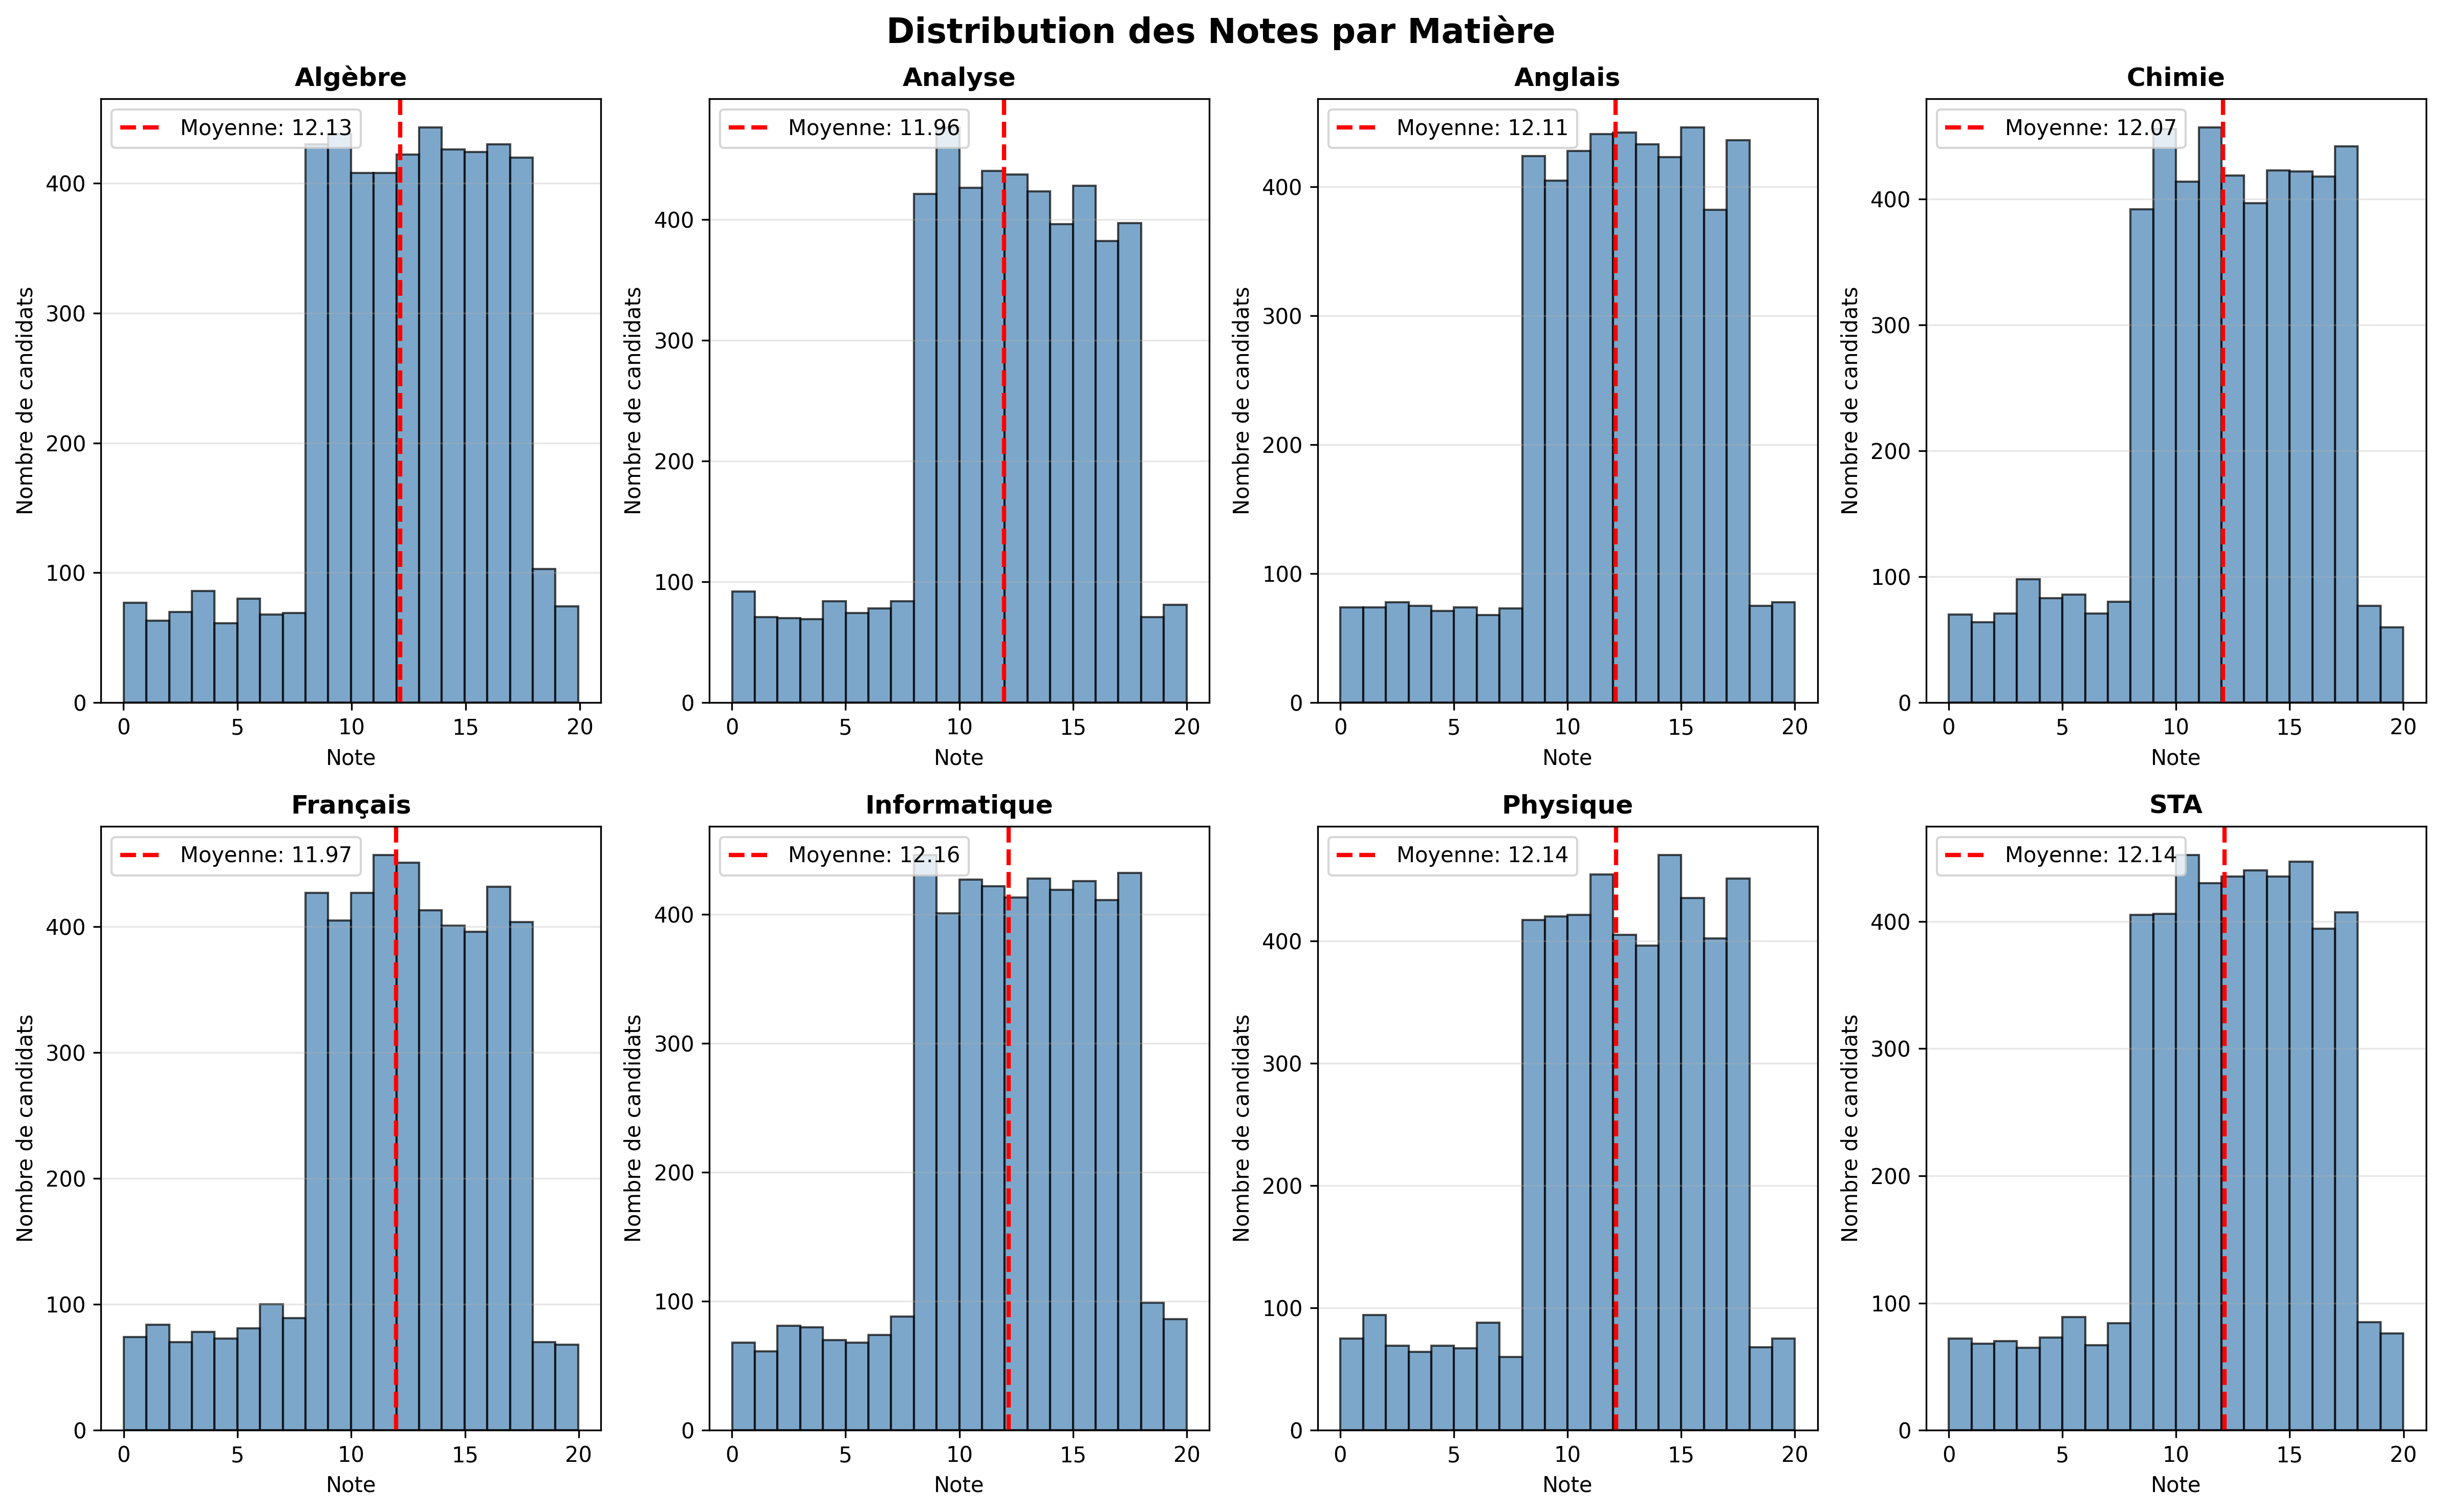


Distribution MP vs PC


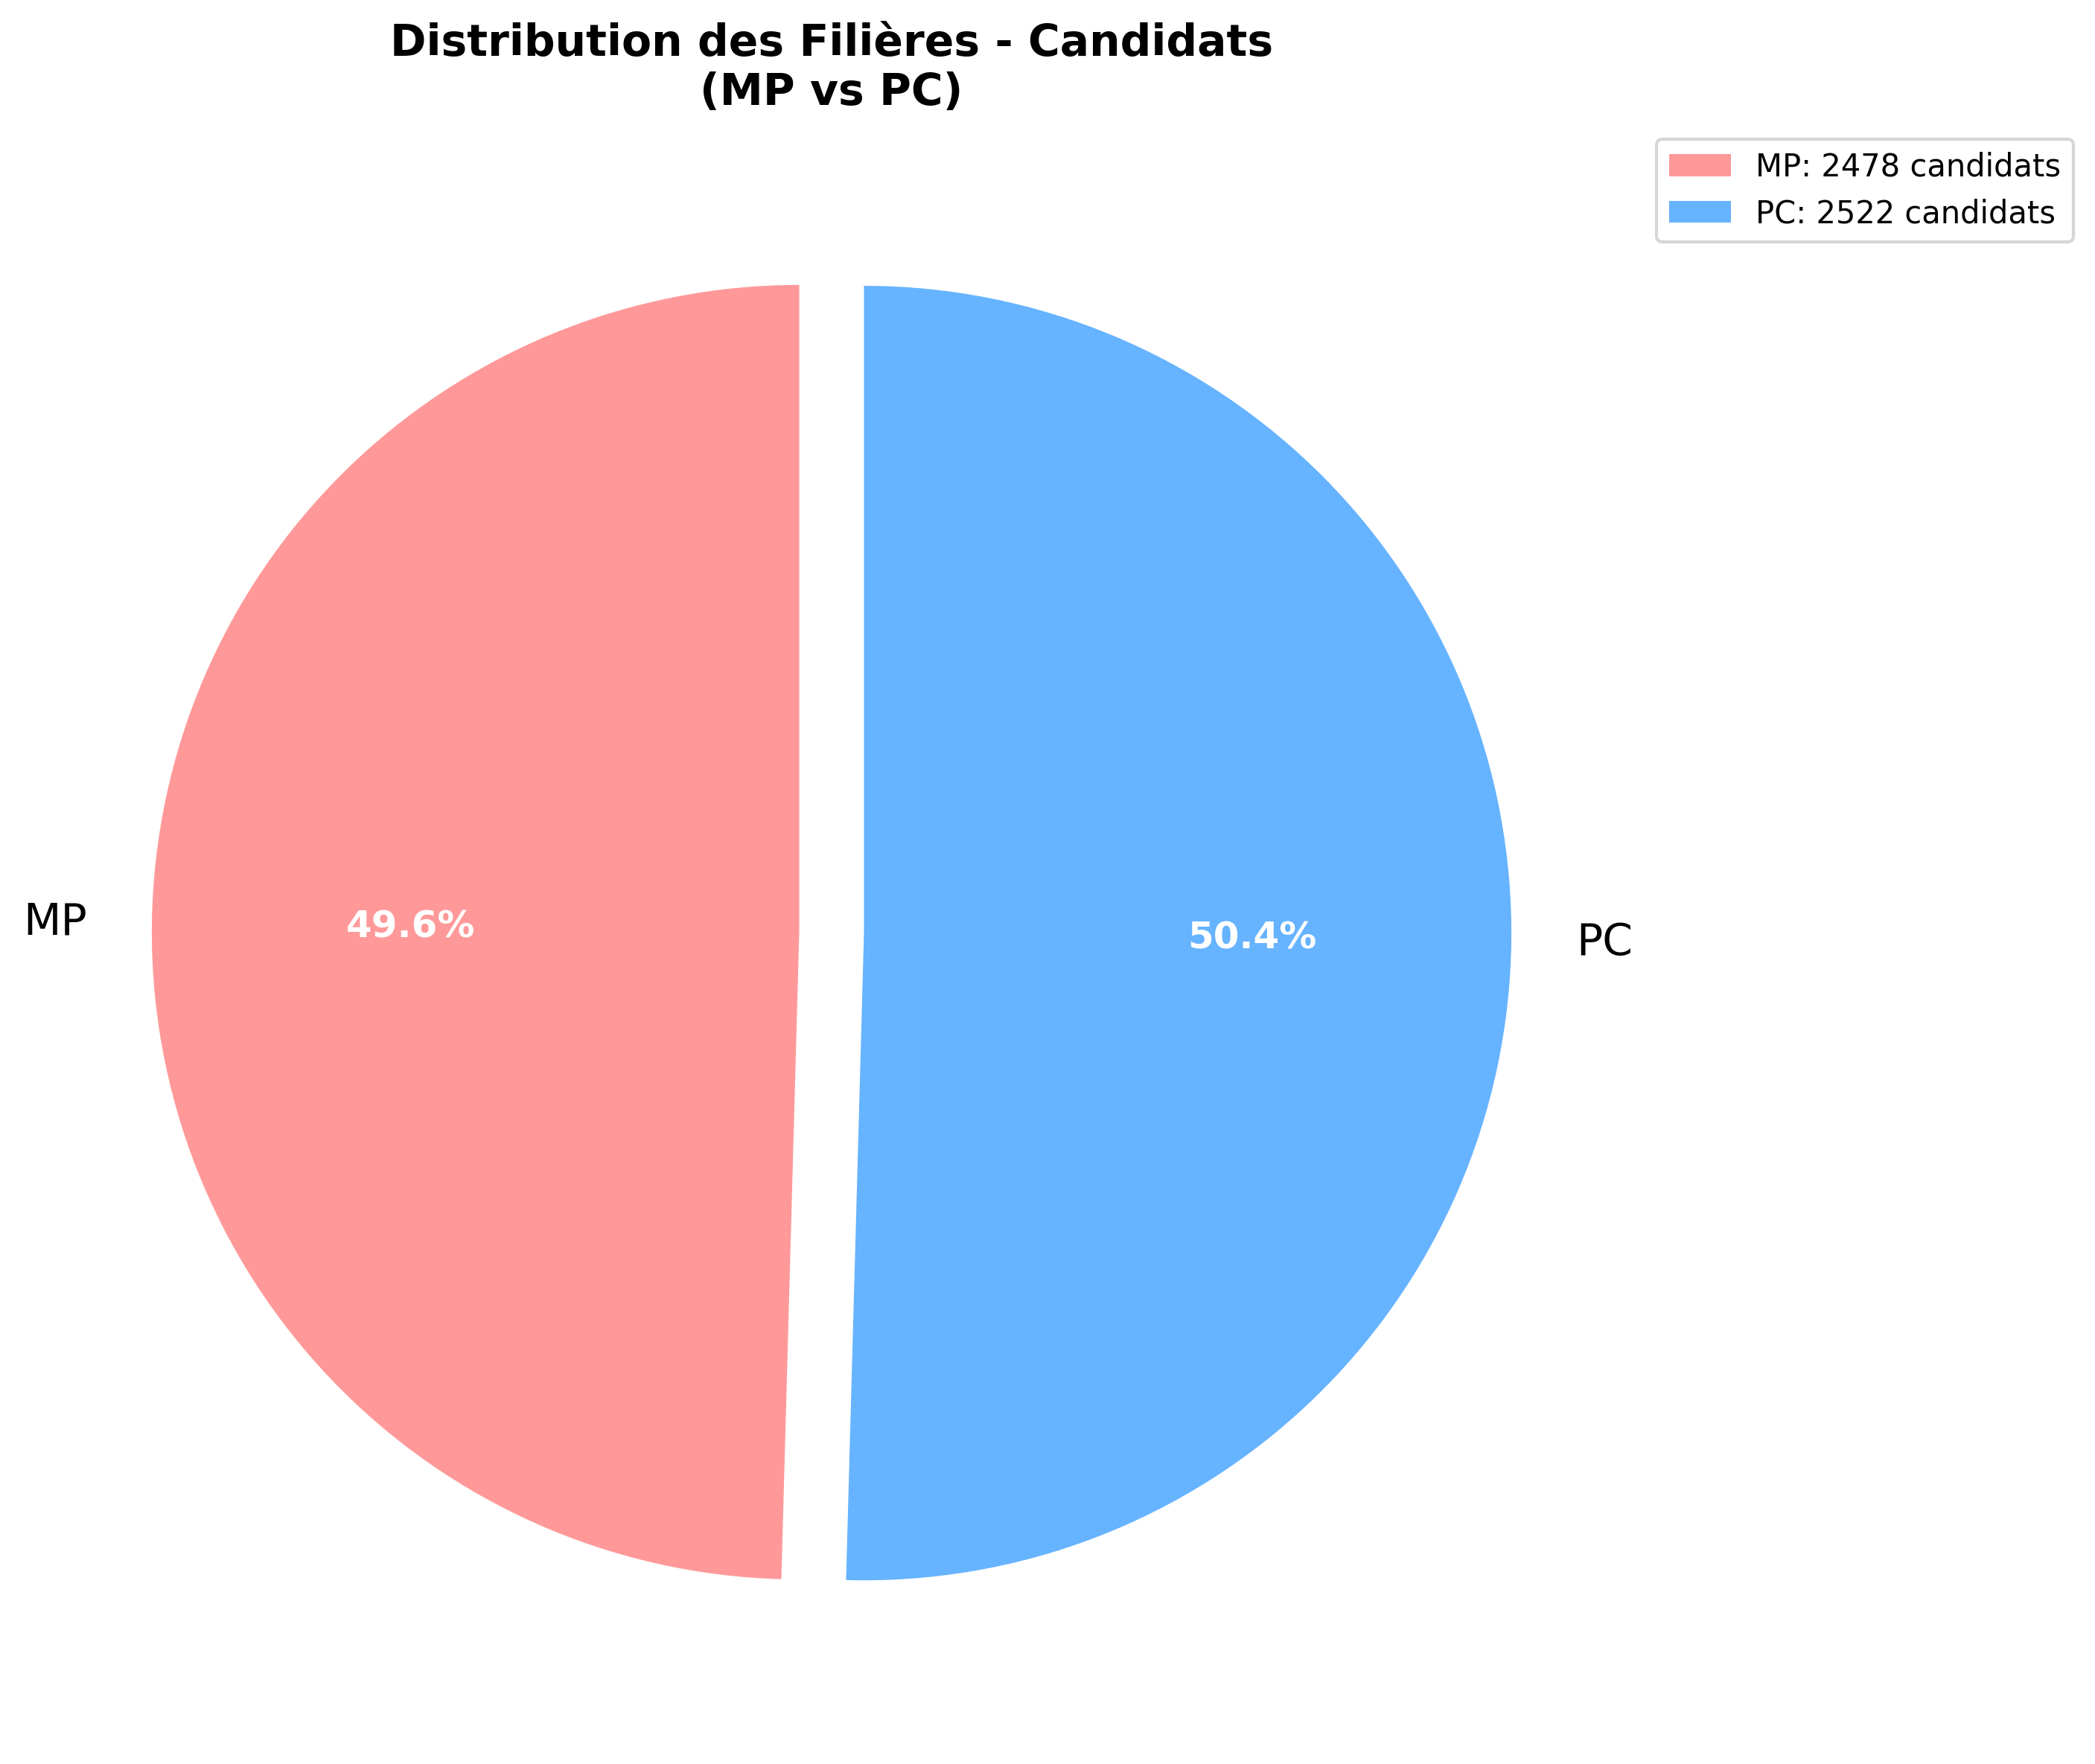


Courbe des moyennes avec ecart-type


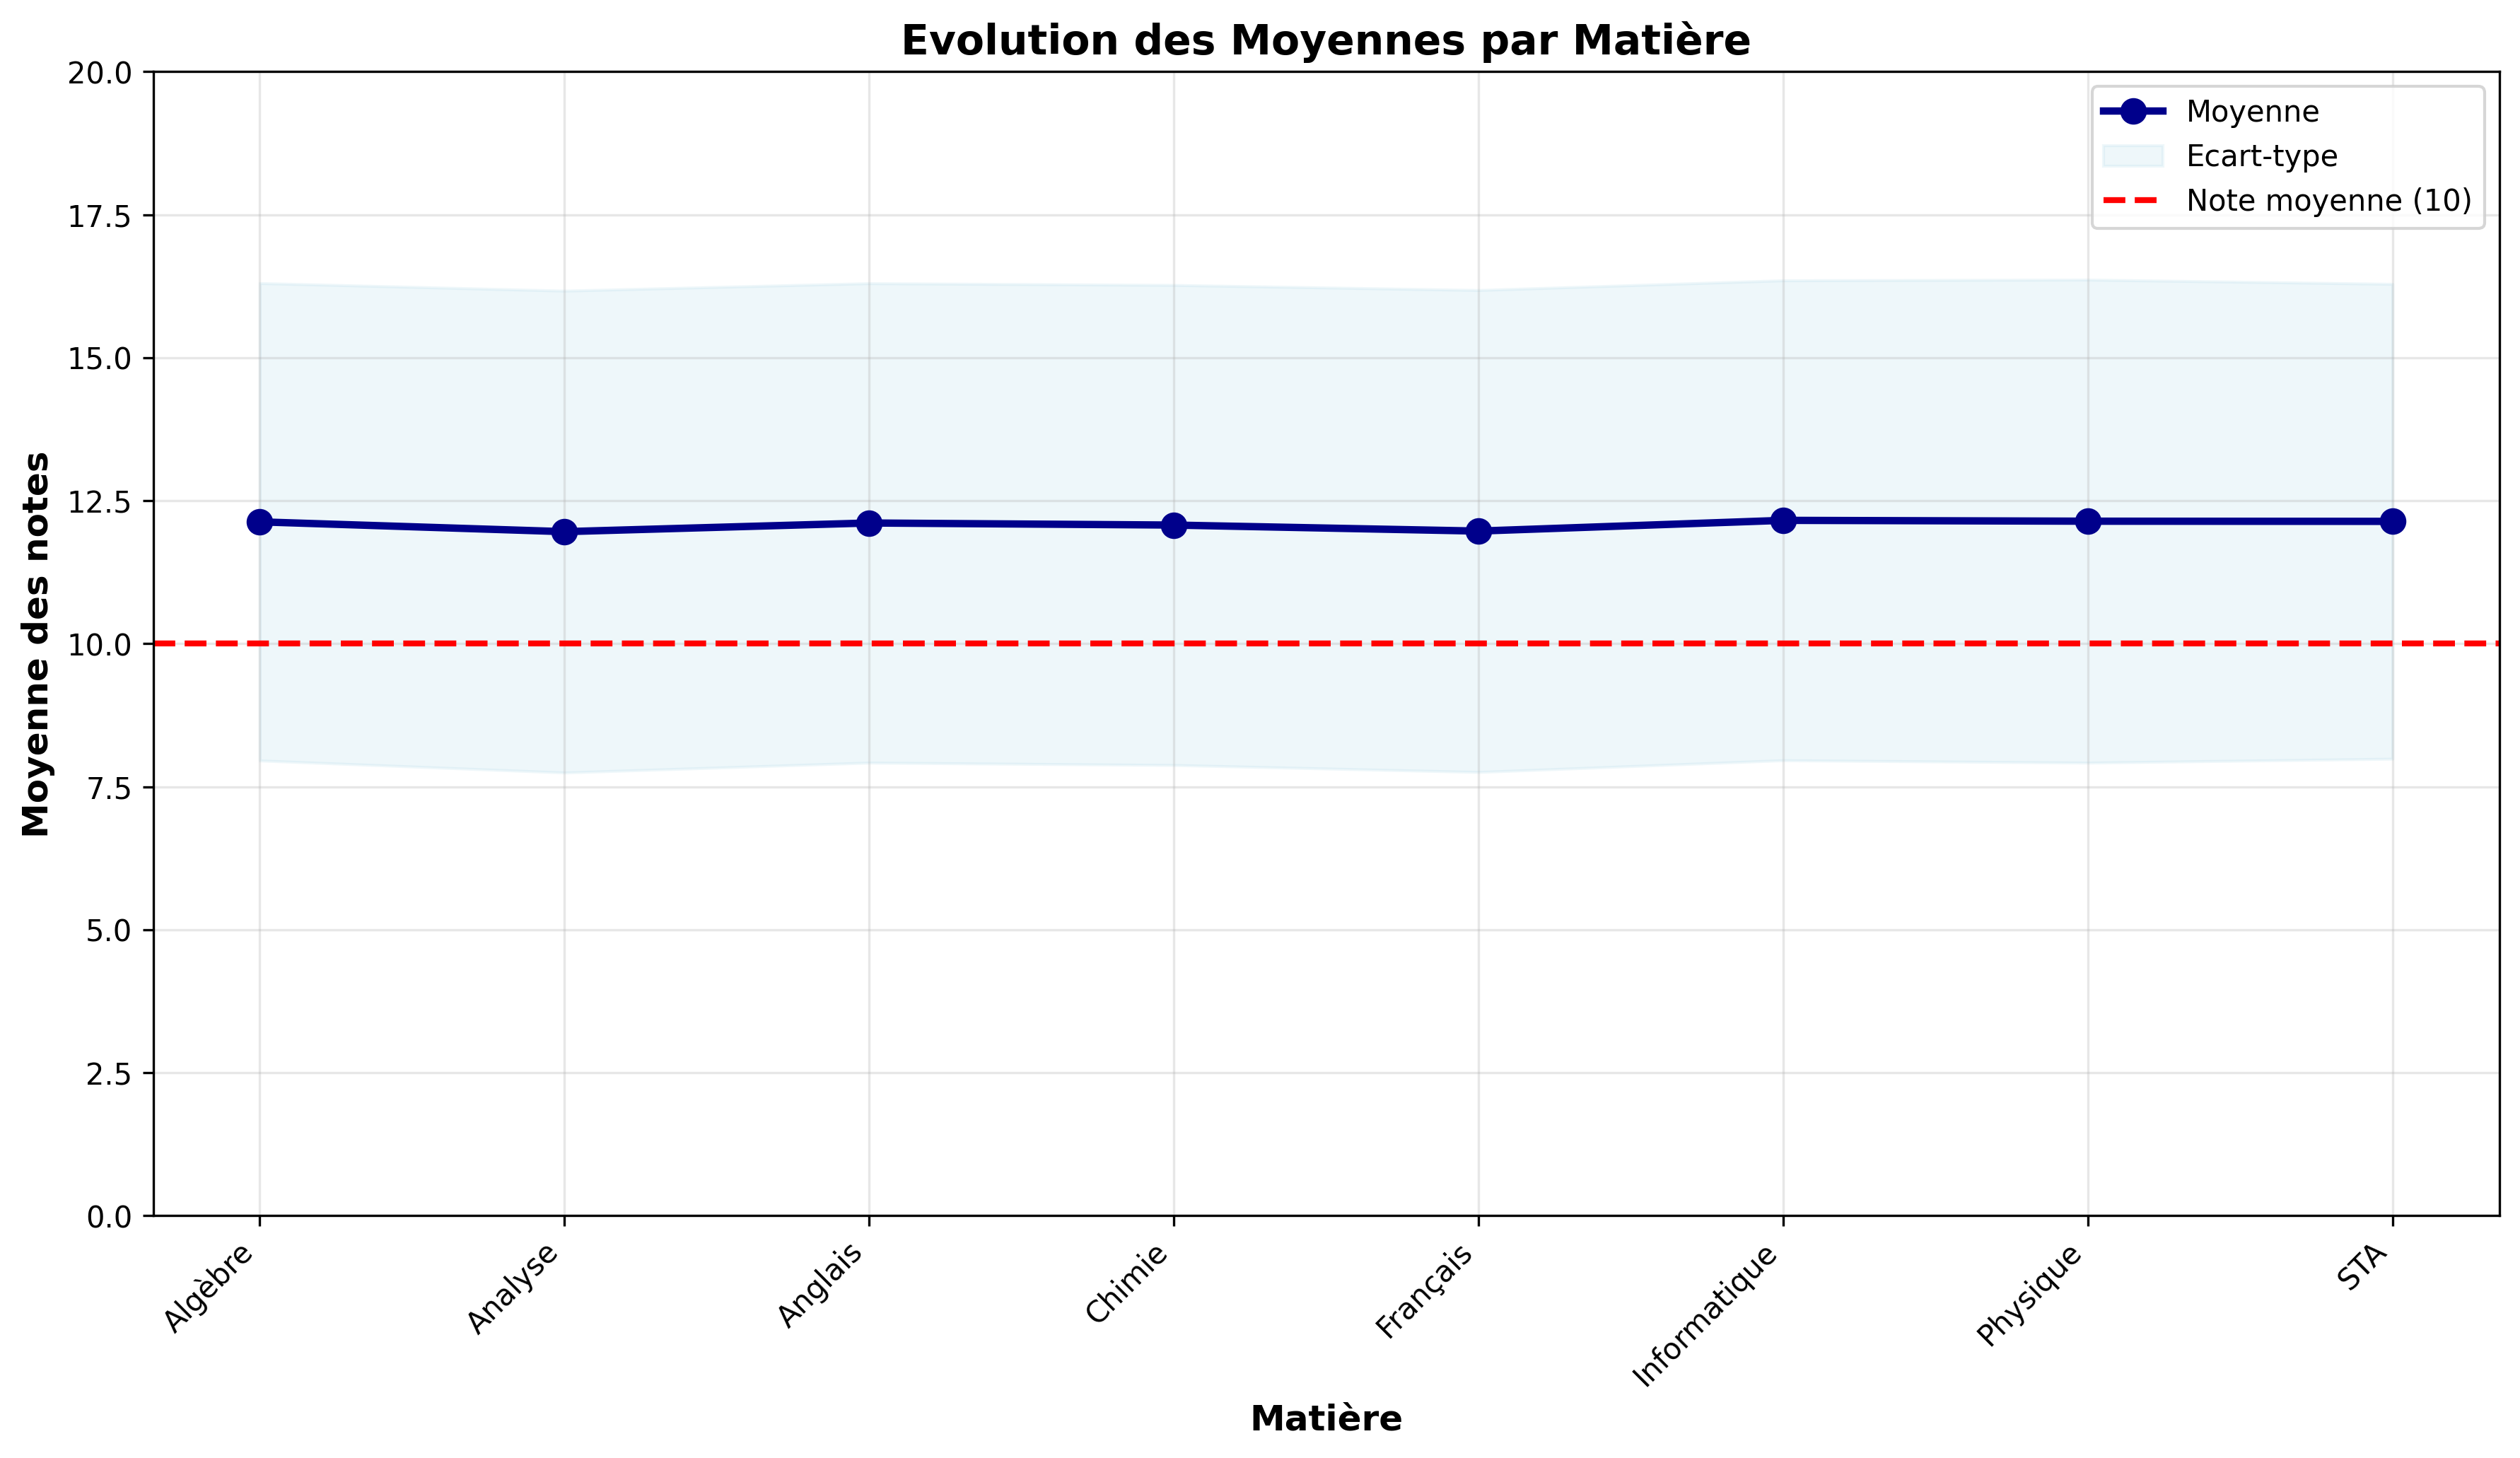


Histogramme des scores FG


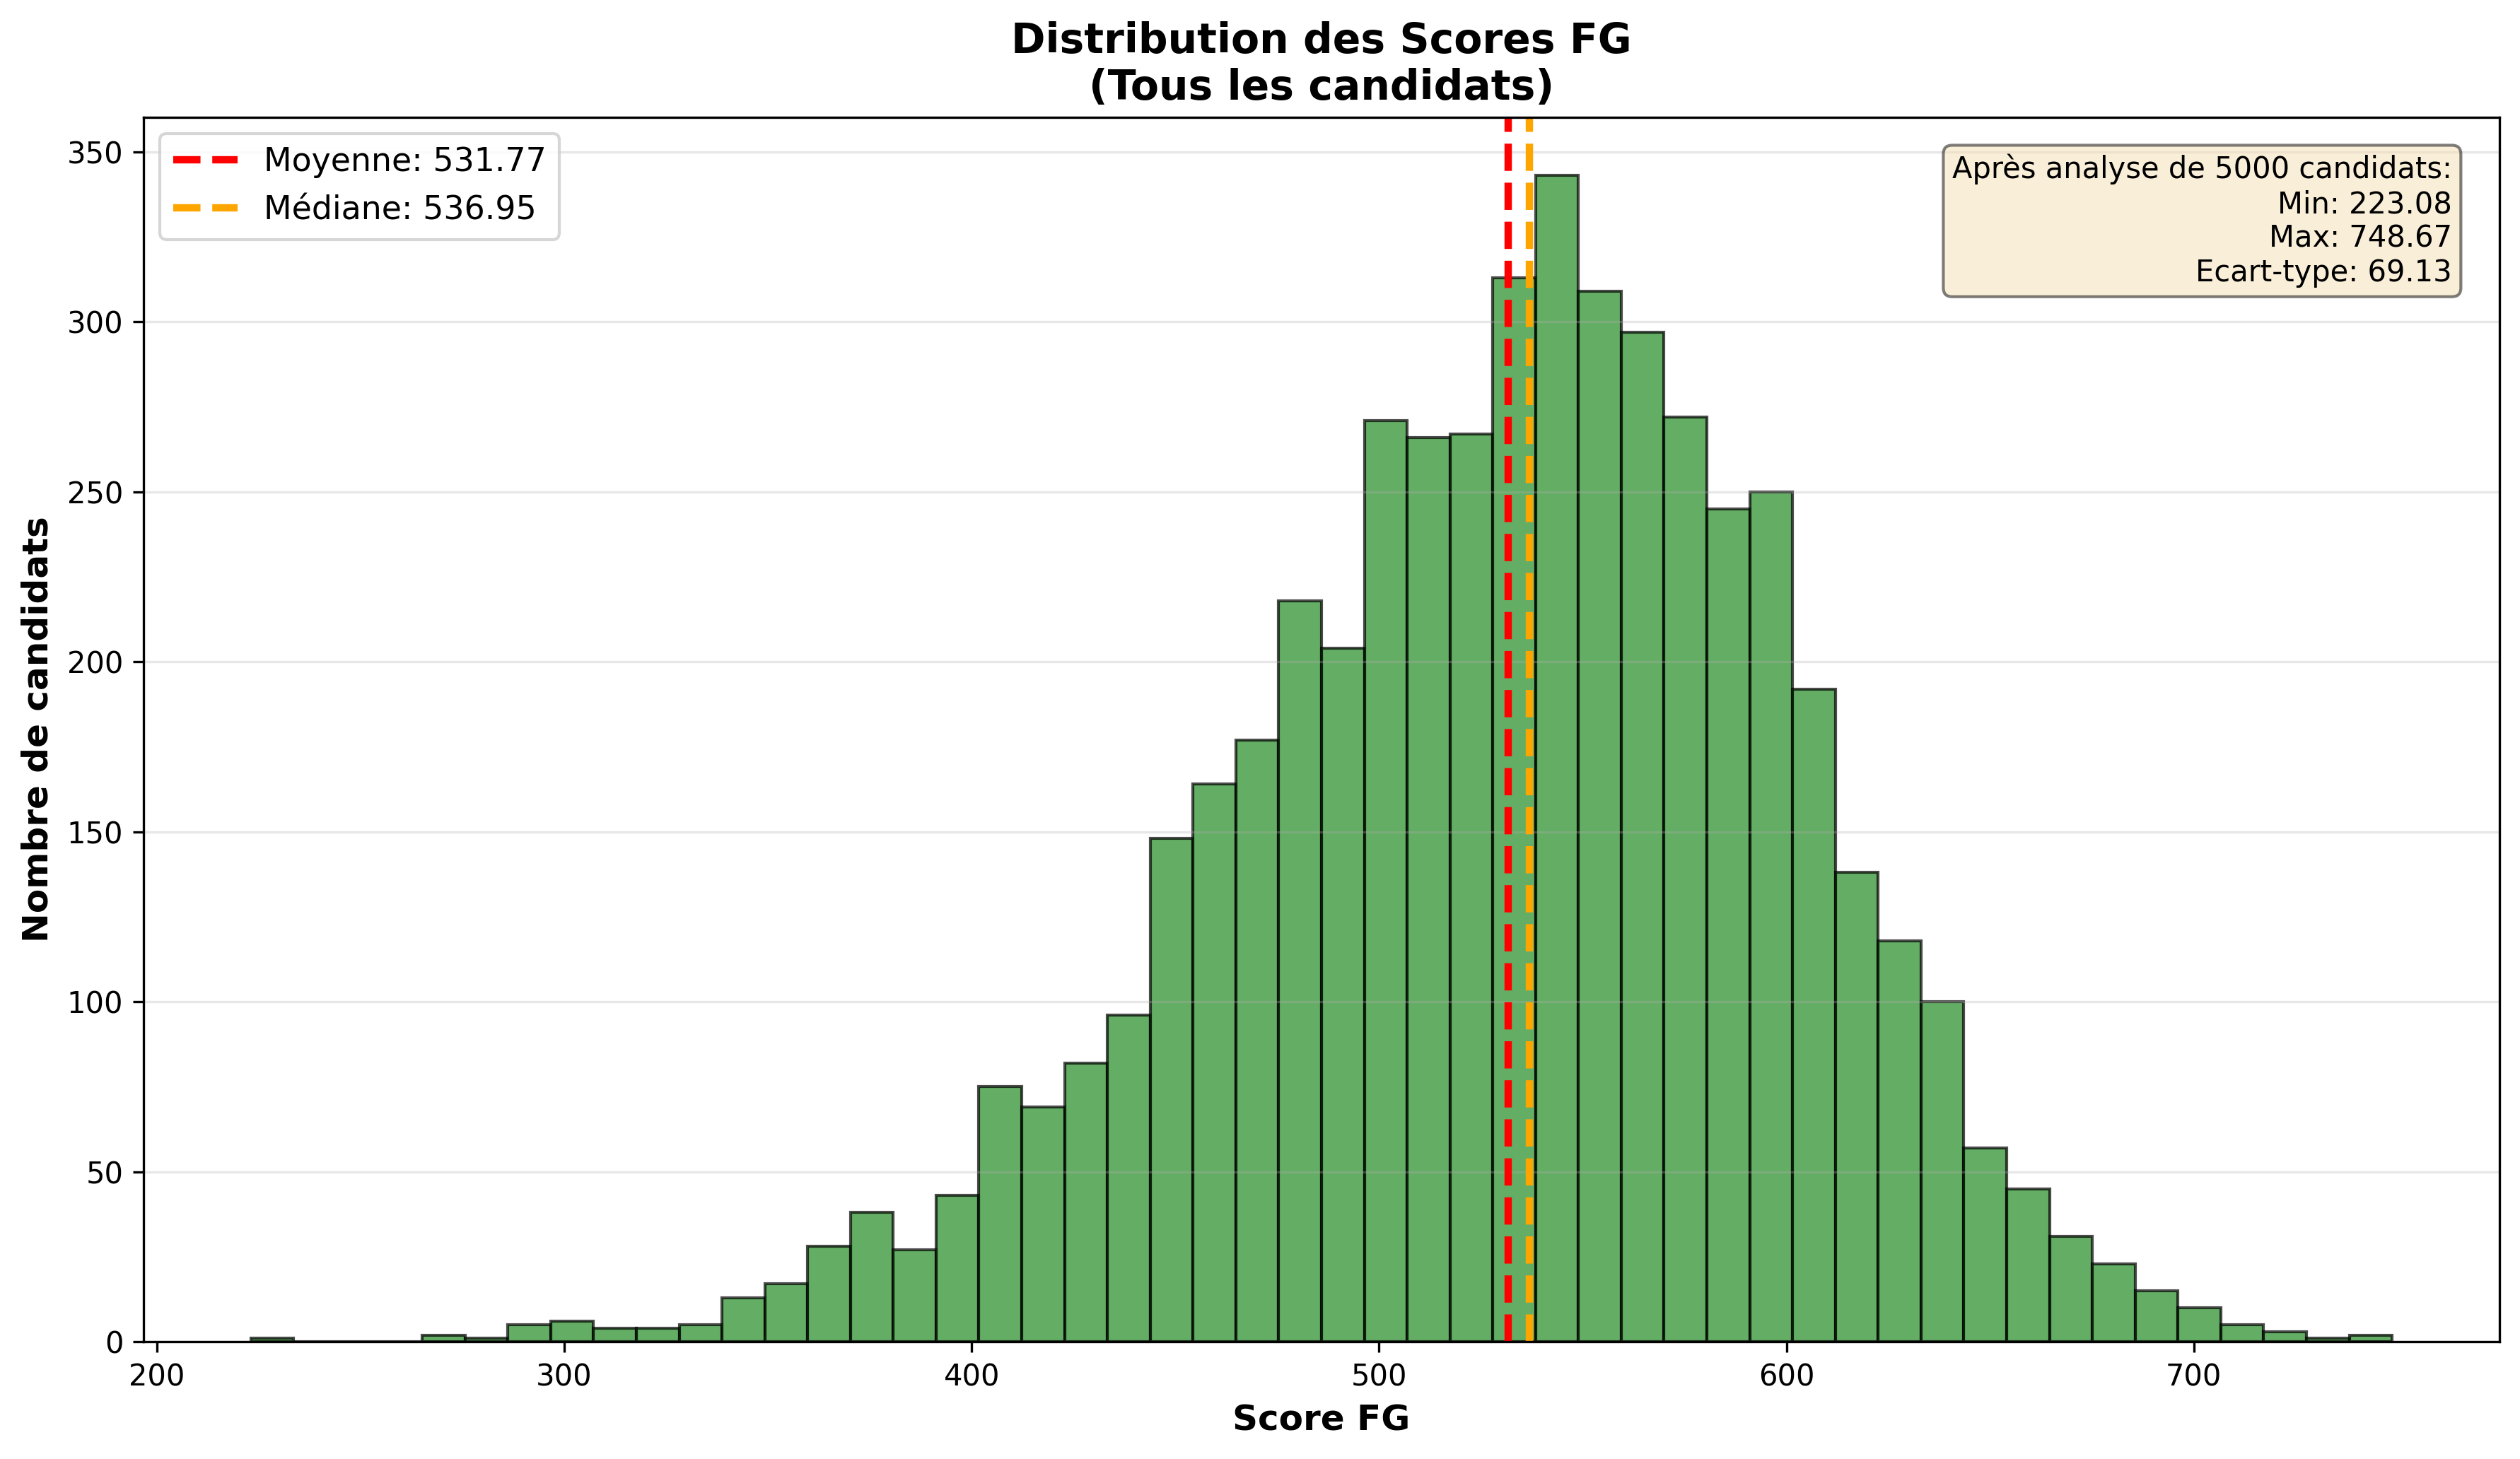


Repartition des affectations par filiere


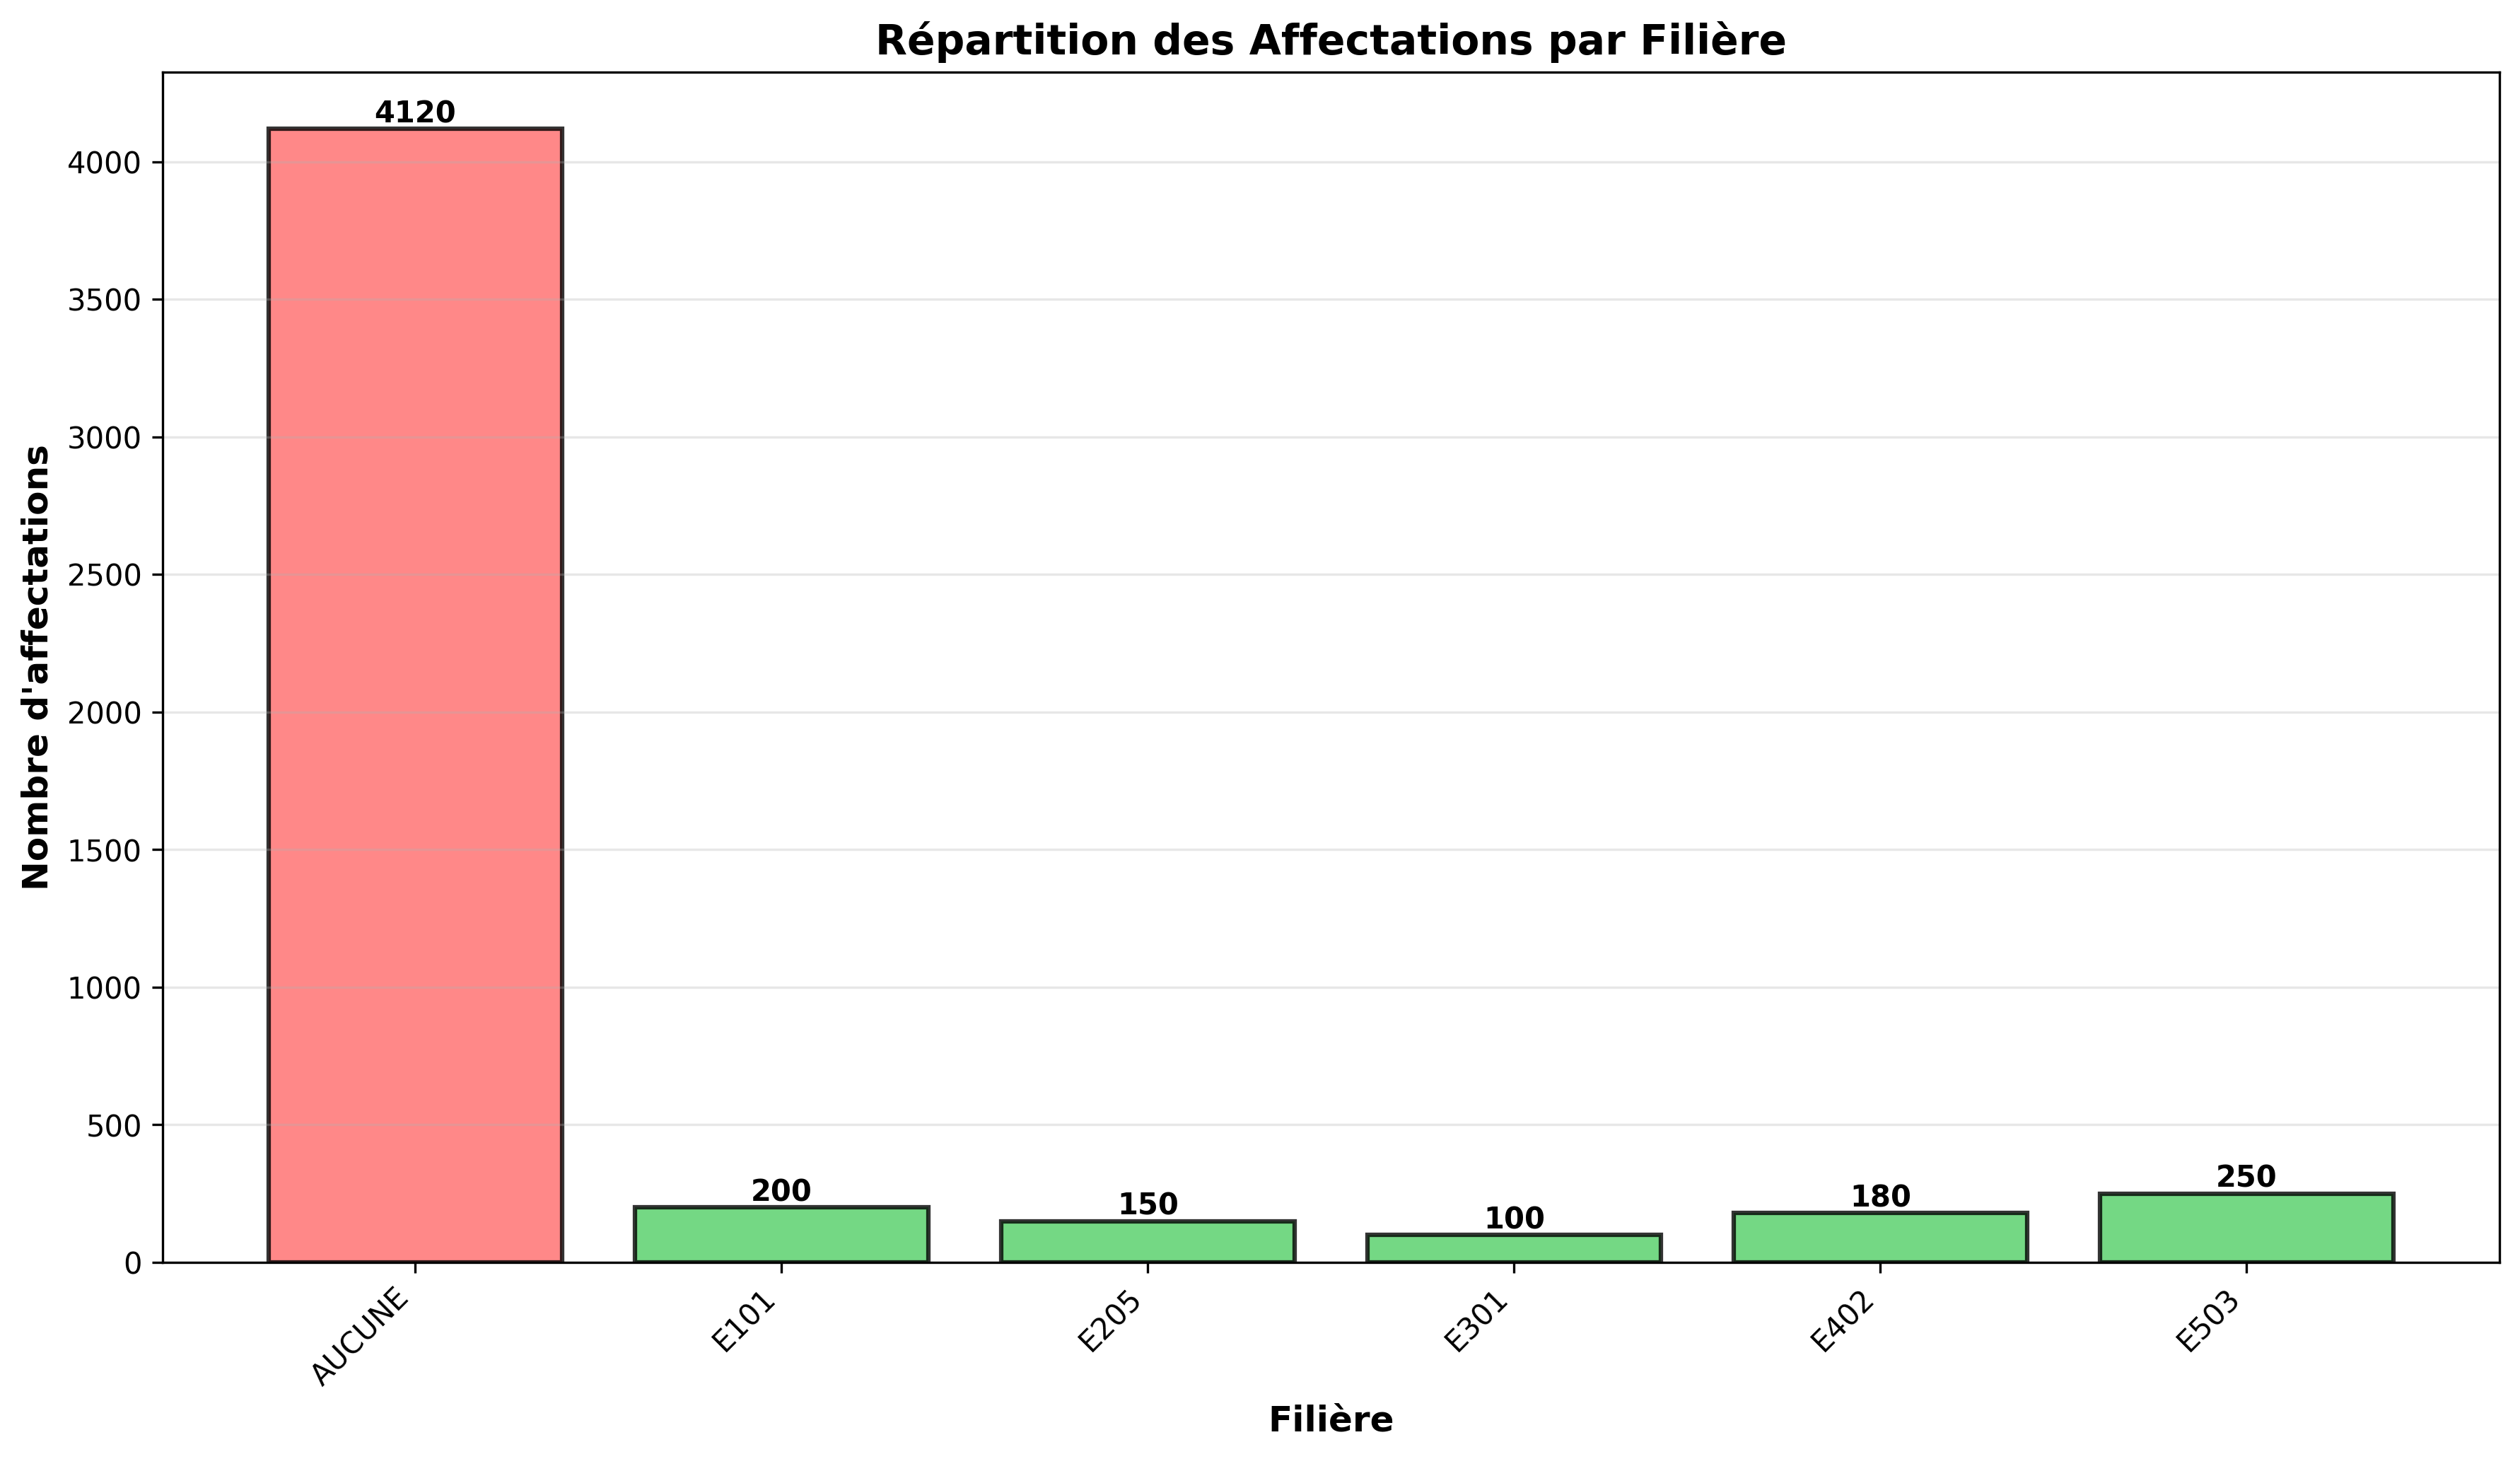

In [9]:
# Afficher les graphiques PNG generes
import os
from IPython.display import Image as IPImage, display

dossier_visuals = "visualisations"

fichiers = [
    ("Histogrammes_Matieres.png", "Histogrammes des notes par matiere"),
    ("Distribution_Filieres.png", "Distribution MP vs PC"),
    ("Courbe_Moyennes.png", "Courbe des moyennes avec ecart-type"),
    ("Histogramme_FG.png", "Histogramme des scores FG"),
    ("Repartition_Affectations.png", "Repartition des affectations par filiere")
]

for nom_fichier, titre in fichiers:
    chemin = os.path.join(dossier_visuals, nom_fichier)
    print(f"\n{titre}")
    if os.path.exists(chemin):
        display(IPImage(filename=chemin))
    else:
        print(f"Fichier manquant: {nom_fichier}")

---
## CONCLUSIONS ET SYNTHÈSE

### Objectifs Atteints 

In [ ]:
# Resume final
print("="*70)
print("RESUME FINAL DU PROJET")
print("="*70 + "\n")

print("DATASET GENERE :")
print("  - Candidats        : 5,000")
print("  - Notes totales    : 40,000 (5000 x 8)")
print("  - Choix totaux     : 15,000 (5000 x 3)")
print("  - Filieres         : 5 (E101 a E503)")
print("  - Capacite totale  : 880 places")

print("\nMAPREDUCE :")
print("  - Scores FG calcules : 5000")
print(f"  - Score minimum      : {min(scores_fg):.2f}")
print(f"  - Score maximum      : {max(scores_fg):.2f}")
print(f"  - Score moyen        : {np.mean(scores_fg):.2f}")

print("\nHIVE :")
print("  - Tables creees    : 5")
print("  - Requetes         : 5 analytiques")
print("  - Matieres etudiees: 8")

print("\nHBASE :")
total_affectes = sum(n for k, n in affectations.items() if k != 'AUCUNE')
total_refuses = affectations.get('AUCUNE', 0)
print(f"  - Candidats affectes : {total_affectes}")
print(f"  - Candidats non affectes : {total_refuses}")

print("\nVISUALISATIONS :")
print("  - Graphiques PNG   : 5")
print("  - Resolution       : 300 DPI")
print("  - Format           : PNG")

print("\n" + "="*70)
print("PROJET BIG DATA COMPLETE")
print("="*70)

In [ ]:
# Afficher le chemin et l'environnement Docker
import os
import sys

print("="*70)
print("INFORMATIONS ENVIRONNEMENT")
print("="*70)
print(f"Python version   : {sys.version.split()[0]}")
print(f"Working directory: {os.getcwd()}")
print(f"In Docker?"       + 
      ("  ✓ OUI" if os.path.exists('/.dockerenv') else "  ✗ NON (environnement local)"))
print(f"Platform         : {sys.platform}")
print("="*70)

---
##  CONTEXTE DOCKER

### Infrastructure Containerisée
Ce projet peut être exécuté dans Docker pour une meilleure portabilité et reproductibilité :

**Fichiers Docker fournis :**
- `Dockerfile` - Image avec Python 3.11 + Jupyter + Dépendances
- `docker-compose.yml` - Orchestration des services
- `requirements.txt` - Paquets Python
- `DOCKER_GUIDE.md` - Documentation complète
- `start.bat` (Windows) / `start.sh` (Linux/Mac) - Scripts de lancement

### Démarrage avec Docker

**En 3 commandes :**
```bash
# 1. Construction
docker-compose build

# 2. Lancement
docker-compose up -d

# 3. Accès
# http://localhost:8888
# Ouvrir NOTEBOOK_SOUMISSION.ipynb
```

Ou utiliser le script fourni : `start.bat` (Windows) ou `./start.sh` (Linux/Mac)

---